In [23]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
# Load dataset
df = pd.read_csv("task1_dataset.csv")
df

,date,age,income,loan_amount,credit_score,num_transactions,annual_spend,city,employment_type,loan_type,target
0,2020-01-01,63,63013.191704,2.793898e+05,616.029633,31,6.904324e+05,Bangalore,Unemployed,Auto,294319.227774
1,2020-01-02,20,47161.859481,9.508975e+05,716.561294,33,5.951086e+05,Bangalore,Student,Home,154516.648673
2,2020-01-03,46,55234.345094,NaN,564.991196,28,9.989912e+05,Delhi,Student,Auto,252354.507062
3,2020-01-04,52,74712.765160,4.311590e+05,572.736033,25,7.007800e+05,Chennai,Unemployed,Home,226719.203929
4,2020-01-05,56,82830.588108,2.727301e+05,813.630055,34,1.105784e+06,Delhi,Unemployed,Home,225838.346929
...,...,...,...,...,...,...,...,...,...,...,...
1995,2025-06-18,41,70630.379654,1.525158e+06,732.884459,31,5.963429e+05,Hyderabad,Salaried,Home,300442.168194
1996,2025-06-19,41,63361.024697,3.055093e+05,546.198231,33,9.203431e+05,Delhi,Salaried,Auto,289954.022081
1997,2025-06-20,50,60798.190941,2.596022e+05,639.065695,27,6.858628e+05,Delhi,Unemployed,Home,195312.531902
1998,2025-06-21,35,56771.242421,3.296667e+05,578.375678,34,1.133484e+06,Mumbai,Unemployed,Education,263439.565538


In [25]:

# Explore dataset
print(df.head())
print(df.info())

         date  age        income    loan_amount  credit_score  \
0  2020-01-01   63  63013.191704  279389.811431    616.029633   
1  2020-01-02   20  47161.859481  950897.454063    716.561294   
2  2020-01-03   46  55234.345094            NaN    564.991196   
3  2020-01-04   52  74712.765160  431159.014692    572.736033   
4  2020-01-05   56  82830.588108  272730.054365    813.630055   

   num_transactions  annual_spend       city employment_type loan_type  \
0                31  6.904324e+05  Bangalore      Unemployed      Auto   
1                33  5.951086e+05  Bangalore         Student      Home   
2                28  9.989912e+05      Delhi         Student      Auto   
3                25  7.007800e+05    Chennai      Unemployed      Home   
4                34  1.105784e+06      Delhi      Unemployed      Home   

          target  
0  294319.227774  
1  154516.648673  
2  252354.507062  
3  226719.203929  
4  225838.346929  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 

In [26]:
# Handle missing values
df["income"] = df["income"].fillna(df["income"].mean())
df["loan_amount"] = df["loan_amount"].fillna(df["loan_amount"].median())
df["credit_score"] = df["credit_score"].fillna(df["credit_score"].mean())
df["annual_spend"] = df["annual_spend"].fillna(df["annual_spend"].median())

In [27]:
# Drop date column
if "date" in df.columns:
    df.drop("date", axis=1, inplace=True)

In [28]:
# Encode categorical columns automatically
categorical_cols = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=categorical_cols, dtype=int)

In [29]:
# Feature scaling
scaler = MinMaxScaler()
num_cols = ['age','income','loan_amount','credit_score','num_transactions','annual_spend','target']
df[num_cols] = scaler.fit_transform(df[num_cols])


In [30]:
# Split features and target
X = df.drop("target", axis=1)
y = df["target"]

In [31]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# Train KNN regression model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [33]:
# Predictions
y_pred = knn.predict(X_test)


In [34]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 0.02399354805530134
R2 Score: -0.15043059010189652


In [35]:
# Elbow method to find best K
mse_values = []
k_values = range(1,21)

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test,pred)
    mse_values.append(mse)

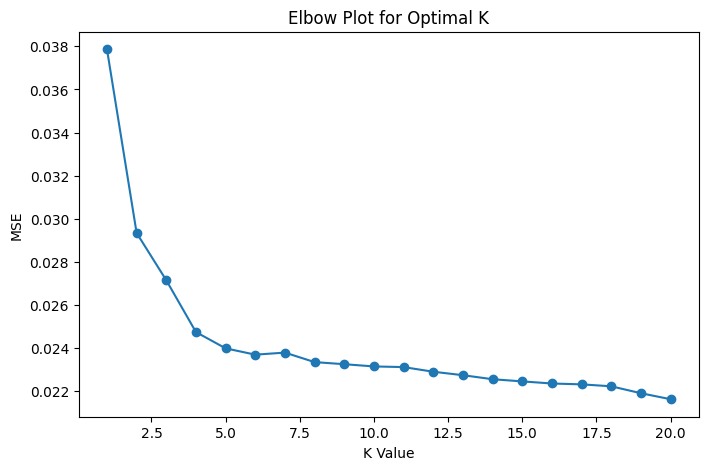

In [36]:
# Plot elbow graph
plt.figure(figsize=(8,5))
plt.plot(k_values, mse_values, marker='o')
plt.xlabel("K Value")
plt.ylabel("MSE")
plt.title("Elbow Plot for Optimal K")
plt.show()

In [37]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Split features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01)
}

# Train and evaluate models
for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_score = r2_score(y_train, y_train_pred)
    test_score = r2_score(y_test, y_test_pred)
    
    print(f"{name}")
    print("Training Accuracy:", train_score)
    print("Testing Accuracy:", test_score)
    print("-------------------------")

Linear Regression
Training Accuracy: 0.16306857322383528
Testing Accuracy: 0.13258248929391536
-------------------------
KNN
Training Accuracy: 0.24522532223631366
Testing Accuracy: -0.15043059010189652
-------------------------
Decision Tree
Training Accuracy: 1.0
Testing Accuracy: -0.15922826771177778
-------------------------
Random Forest
Training Accuracy: 0.9063491236627972
Testing Accuracy: 0.40337086130144195
-------------------------
Ridge
Training Accuracy: 0.16218417630147053
Testing Accuracy: 0.13674712186314353
-------------------------
Lasso
Training Accuracy: 0.0
Testing Accuracy: -0.0006226954425301301
-------------------------
